In [5]:
import numpy as np
import time


class FreezingSoilFDM:
    """
    1D finite difference model for freezing/thawing soil.

    Main features:
    1. Smoothed and physically bounded phi(T), aligned with PINN idea
    2. Apparent heat capacity method:
           C_app = C_eff + L * d(theta)/dT
    3. Implicit solver for better stability
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.L = params['L']                    # latent heat, MJ/m^3
        self.C_i = params['C_i']                # ice heat capacity
        self.C_l = params['C_l']                # liquid water heat capacity
        self.C_f = params['C_f']                # soil skeleton heat capacity
        self.lambda_i = params['lambda_i']      # ice conductivity
        self.lambda_l = params['lambda_l']      # liquid conductivity
        self.lambda_f = params['lambda_f']      # soil skeleton conductivity
        self.eta = params['eta']                # porosity
        self.b = params['b']                    # unfrozen water exponent
        self.T_nabla = params['T_nabla']        # freezing onset temperature

        # ---------------- Smoothing / numerical parameters ----------------
        self.k_phi = params.get('k_phi', 8.0)
        self.eps_phi = params.get('eps_phi', 1e-6)
        self.diff_h = params.get('diff_h', 1e-4)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed pore liquid water fraction phi(T), with physical constraint:
            0 <= phi <= 1

        Frozen-side formula:
            phi_frozen = |T_nabla|^b * |T|^{-b}
        Then smoothly blended with phi=1 using sigmoid around T_nabla.
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        step = 1.0 / (1.0 + np.exp(-self.k_phi * (T - self.T_nabla)))

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        phi = np.clip(phi, 0.0, 1.0)
        return phi

    def unfrozen_water_content(self, T):
        return self.eta * self.pore_water_content(T)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return ((1.0 - self.eta) * self.C_f
                + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i))

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return ((1.0 - self.eta) * self.lambda_f
                + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i))

    def dtheta_dT(self, T):
        """
        Numerical derivative of theta(T).
        Central difference is used for robustness.
        """
        h = self.diff_h
        theta_plus = self.unfrozen_water_content(T + h)
        theta_minus = self.unfrozen_water_content(T - h)
        return (theta_plus - theta_minus) / (2.0 * h)

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT

        To avoid numerical failure, enforce a small positive lower bound.
        """
        C_eff = self.effective_heat_capacity(T)
        dtheta = self.dtheta_dT(T)
        C_app = C_eff + self.L * dtheta

        # Numerical safeguard
        C_app = np.maximum(C_app, 1e-6)
        return C_app

    # ============================================================
    # Grid initialization
    # ============================================================
    def initialize(self, Nx=100, Nt=5000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # ============================================================
    # Utilities
    # ============================================================
    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        C_eff = self.effective_heat_capacity(T)
        lam = self.effective_conductivity(T)
        dtheta = self.dtheta_dT(T)
        C_app = self.apparent_heat_capacity(T)

        print("Diagnostics:")
        print(f"  T range        : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range      : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  C_eff range    : [{np.min(C_eff):.6f}, {np.max(C_eff):.6f}]")
        print(f"  lambda range   : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dtheta/dT range: [{np.min(dtheta):.6f}, {np.max(dtheta):.6f}]")
        print(f"  C_app range    : [{np.min(C_app):.6f}, {np.max(C_app):.6f}]")

    # ============================================================
    # Implicit solver
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Implicit solver:
            C_app(T^n) * (T^{n+1} - T^n)/dt = div( lambda(T^n) grad(T^{n+1}) )

        This is semi-implicit:
        - material properties are evaluated at old time step
        - spatial operator acts on new temperature
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            C_app = self.apparent_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            # Interior nodes
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN or Inf detected at time step {n}.")

            self.T_field[:, n] = T_new
            T = T_new

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Save results
    # ============================================================
    def save_results(self, filename='fdm_results.npz'):
        if self.T_field is None:
            raise RuntimeError("No results to save.")

        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi,
                'diff_h': self.diff_h
            }
        )
        print(f"Results saved to {filename}")


# if __name__ == "__main__":
#     params = {
#         'L': 334,
#         'C_i': 1.672,
#         'C_l': 4.18,
#         'lambda_i': 2.210e-6 * 8.64e4,
#         'lambda_l': 0.465e-6 * 8.64e4,
#         'lambda_f': 2e-6 * 8.64e4,
#         'C_f': 1.6,
#         'eta': 0.4,
#         'b': 0.7,
#         'T_nabla': -0.3,
#         'k_phi': 8.0,
#         'eps_phi': 1e-6,
#         'diff_h': 1e-4
#     }

#     model = FreezingSoilFDM(params)

#     # You can adjust these numbers if needed
#     model.initialize(Nx=100, Nt=5000, Lx=5.0, T_total=365.0)

#     T_field = model.solve_implicit(verbose=True)

#     model.save_results("fdm_results.npz")

In [6]:
if __name__ == "__main__":
    params = {
        'L': 334,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'C_f': 1.6,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 8.0,
        'eps_phi': 1e-6
    }

    model = FreezingSoilFDM(params)
    model.initialize(Nx=100, Nt=5000, Lx=5.0, T_total=365.0)
    T_field = model.solve_implicit()
    model.save_results("fdm_results.npz")

    print("T min =", T_field.min())
    print("T max =", T_field.max())
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

Starting implicit FDM solver...
Diagnostics:
  T range        : [-11.926392, 1.000000]
  phi range      : [0.075933, 1.000000]
  C_eff range    : [1.704976, 2.632000]
  lambda range   : [0.119750, 0.175478]
  dtheta/dT range: [-0.002352, 0.508514]
  C_app range    : [1.845853, 172.302663]
  Progress: 10.0%   elapsed: 0.4s
  Progress: 20.0%   elapsed: 0.7s
  Progress: 30.0%   elapsed: 1.1s
  Progress: 40.0%   elapsed: 1.5s
  Progress: 50.0%   elapsed: 1.8s
  Progress: 60.0%   elapsed: 2.2s
  Progress: 70.0%   elapsed: 2.5s
  Progress: 80.0%   elapsed: 2.8s
  Progress: 90.0%   elapsed: 3.2s
Implicit solution completed in 3.5s
Diagnostics:
  T range        : [-11.926392, 1.000000]
  phi range      : [0.075933, 1.000000]
  C_eff range    : [1.704976, 2.632000]
  lambda range   : [0.119750, 0.175478]
  dtheta/dT range: [-0.001510, 0.520125]
  C_app range    : [2.126896, 176.236557]
Results saved to fdm_results.npz
T min = -12.079999976463661
T max = 20.13999734247141
Surface final T = -11.9

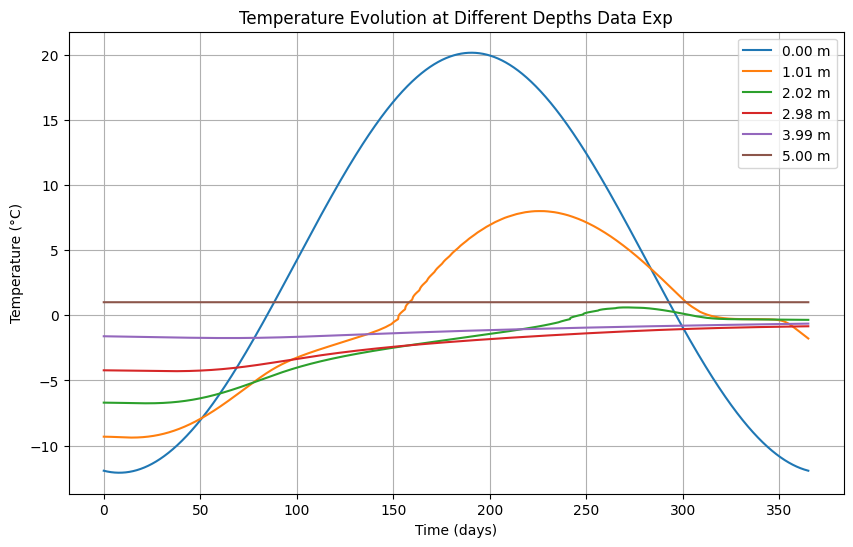

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 加载数据 ----------
data = np.load('fdm_results.npz')
x = data['x']               # 深度 (m), shape (Nx,)
t = data['t']               # 时间 (day), shape (Nt,)
T = data['T_field']         # 温度场 (°C), shape (Nx, Nt)

# ---------- 选择关注的深度（单位：米）----------
depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]   # 可自定义
# depths_of_interest = [0.5, 1.5, 2.5, 3.5, 4.5, 5.0]   # 可自定义

plt.figure(figsize=(10, 6))
for d in depths_of_interest:
    # 找到与目标深度最接近的网格索引
    idx = np.argmin(np.abs(x - d))
    actual_depth = x[idx]
    plt.plot(t, T[idx, :], label=f'{actual_depth:.2f} m')

plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Evolution at Different Depths Data Exp')
plt.legend()
plt.grid(True)
plt.show()